In [22]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [23]:
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [24]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
if not os.path.exists(behave_dir):
    os.mkdir(behave_dir)


In [25]:
%%time
fictrac_data={}
for num in fly_nums:
    fictrac_data[num]={}
    fly_num = f'fly_{num}'
    func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
    vision_path = os.path.join(func_path,'func_0', 'visual')
    ### Load Photodiode ###
    t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
    stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
    if stimulus_start_times.shape[0]<150:
        stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

    # *100 puts in units of 10ms, which will match fictrac
    st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

    # get 1ms version to match neural timestamps
    st_ms= [i*10 for i in st_10ms]
    starts_loom = st_10ms
    starts_loom_ms = [n*10 for n in starts_loom]
    fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
    fictrac_raw = brainsss.load_fictrac(fictrac_path)

    fps = 100
    resolution = 10 #desired resolution in ms
    expt_len = fictrac_raw.shape[0]/fps*1000
    behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
    fictrac_data[num]['behave'] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behaviors[0])
    fictrac_data[num]['ts'] = np.arange(0,expt_len,resolution)

loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
CPU times: user 46.3 s, sys: 4.33 s, total: 50.6 s
Wall time: 1min 24s


(180000,)

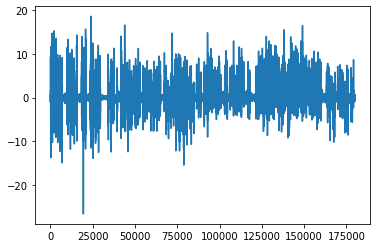

In [26]:
plt.plot(fictrac_data[250]['behave'])
fictrac_data[226]['behave'].shape

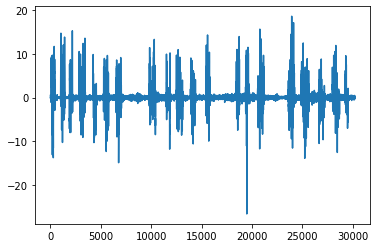

In [27]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

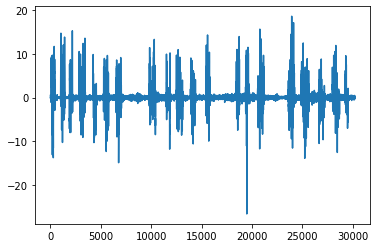

In [28]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

In [29]:
print(np.max(starts_loom))
print(np.max(stimulus_start_times))
print(np.shape(fictrac_data[250]['behave']))

179610
1796.1034
(180000,)


In [30]:
starts_loom[0]

30208

In [31]:
100*60

6000

In [32]:
# 100==1sec, 6000==1min
val_pos=0.1 #10 #
val_neg=-0.1 #-10 #
great_pos=1 #100 #
great_neg=-1 #-100 #
behave_dict={}
start=300
end=start+400
for fly in fictrac_data:
    fly=str(fly)
    behave_dict[fly]={'inc':[],'dec':[],'flat':[]}
    first5=np.asarray(fictrac_data[int(fly)]['behave'][:(starts_loom[0]-6000)])
#     print(np.shape(first5))
    for i in range(len(first5)):
        if i+end<len(first5) and i>6000:
            loom_start=i+start
            pre=np.mean(first5[(loom_start-50):loom_start])
            post=np.mean(first5[(loom_start+50):(loom_start+100)])
            if pre>val_neg and pre<val_pos and post>val_neg and post<val_pos:
#                 print(first5[i:(i+50)].max(),first5[i:(i+50)].min(),pre)
                if behave_dict[fly]['flat']==[]:
                    behave_dict[fly]['flat'].append(loom_start)
                else:
                    if behave_dict[fly]['flat'][-1]+end<=i:
                        behave_dict[fly]['flat'].append(loom_start)
#             elif post>np.abs(pre*2):
            elif pre>great_neg and pre <val_pos and post>great_pos and post>np.abs(pre*2):
                if behave_dict[fly]['inc']==[]:
                    behave_dict[fly]['inc'].append(loom_start)
                else:
                    if behave_dict[fly]['inc'][-1]+end<=i:
                        behave_dict[fly]['inc'].append(loom_start)
#             elif post<pre/2:
            elif pre>great_pos and post<val_pos and post>great_neg and post<pre/2:
                if behave_dict[fly]['dec']==[]:
                    behave_dict[fly]['dec'].append(loom_start)
                else:
                    if behave_dict[fly]['dec'][-1]+end<=i:
                        behave_dict[fly]['dec'].append(loom_start)
    behave_dict[fly]['inc']=np.array(behave_dict[fly]['inc'])
    behave_dict[fly]['dec']=np.array(behave_dict[fly]['dec'])
    behave_dict[fly]['flat']=np.array(behave_dict[fly]['flat'])

In [33]:
behave_dict['226']['inc']

array([ 6520,  7747,  9300, 10473, 12070, 13099, 14139, 15551, 16626,
       17996, 19139, 20184, 21261, 22296, 23329])

In [34]:
avg_be={'inc':[],'dec':[],'flat':[]}
for fly in behave_dict:
    for b in behave_dict[fly]:
        arr=behave_dict[fly][b]
#         print(b)
        for tp in arr:
            avg_be[b].append(fictrac_data[int(fly)]['behave'][(tp-start):(tp+start)])
avg_be['inc']=np.array(avg_be['inc'])
print(f'Inc: {avg_be["inc"].shape}')
avg_be['dec']=np.array(avg_be['dec'])
print(f'Dec: {avg_be["dec"].shape}')
avg_be['flat']=np.array(avg_be['flat'])
print(f'Flat: {avg_be["flat"].shape}')

Inc: (142, 600)
Dec: (140, 600)
Flat: (144, 600)


In [35]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

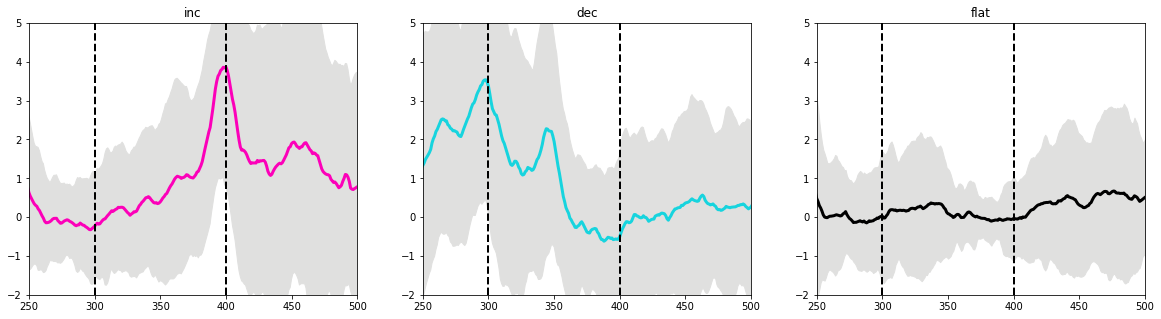

In [36]:
fig,axs=plt.subplots(1,len(list(avg_be.keys())),figsize=(20,5))
for i,be in enumerate(avg_be):
    mean_trace=np.mean(avg_be[be], axis=0)
    std_trace=np.std(avg_be[be], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline((start), linewidth=2, linestyle='--', color='k')
    axs[i].axvline((start+100), linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(250, 500);
    axs[i].set_title(be);


In [37]:
print(behave_dict.keys())
print(behave_dict['226'].keys())
print(behave_dict['226']['inc'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat'])
[ 6520  7747  9300 10473 12070 13099 14139 15551 16626 17996 19139 20184
 21261 22296 23329]


In [38]:
for fly in behave_dict:
    for be in behave_dict[fly]:
        behave_dict[fly][be]=behave_dict[fly][be]*10

In [39]:
# new_event_name='first_3'
# event_list=behave_dict

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)

In [40]:
fly_name='226'
be='inc'
starts_loom_ms = behave_dict[fly_name][be]
# starts_loom_ms=np.sort(starts_loom_ms)

bin_start = -3000; bin_end = 3000; bin_size = 100 #ms

bins_array=[]
for loom in starts_loom_ms:
#     print(loom)
    start=loom+bin_start
    end=loom+bin_end-bin_size   # why did i subtract out bin size??? 
#     edges=[start,end]
    bins_array.append(start)
    bins_array.append(end)
# bins_test=np.vstack(bins_test)
bins_array=np.array(bins_array)
bins_shape=np.shape(bins_array)

In [41]:
np.diff(bins_array)

array([ 5900,  6370,  5900,  9630,  5900,  5830,  5900, 10070,  5900,
        4390,  5900,  4500,  5900,  8220,  5900,  4850,  5900,  7800,
        5900,  5530,  5900,  4550,  5900,  4870,  5900,  4450,  5900,
        4430,  5900])

In [42]:
10000/100

100.0